In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
import os, shutil
import keras
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np 

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Train2",
  image_size=(224, 224),
  batch_size=16,
  )
val_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Validation2",
  image_size=(224, 224),
  batch_size=16)


Found 160 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [4]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal"), 
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)



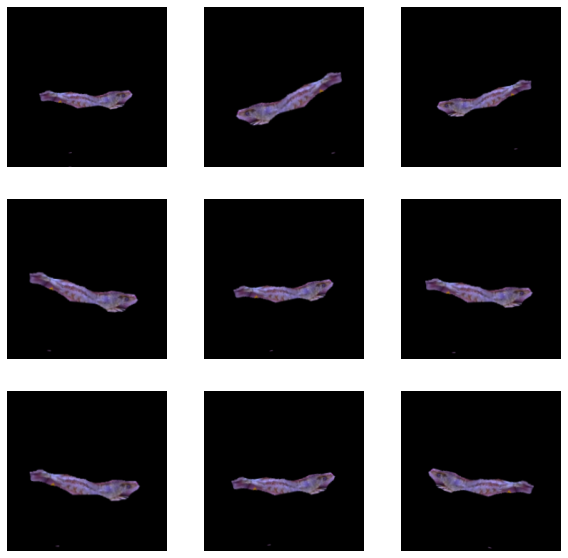

In [5]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
normalization_layer = layers.Rescaling(1./255)

In [8]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image)) 

0.0 0.8456584


In [9]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization,Conv2D,Activation,MaxPooling2D,Dropout,GlobalMaxPooling2D

In [10]:
opt = tf.optimizers.Adam(learning_rate=0.001)

In [11]:
def make_model(input_shape, num_classes):
    
    from tensorflow.keras.optimizers import Adam
    model = models.Sequential()
    
    model.add(layers.Conv2D(128, (2, 2), activation='relu', input_shape = input_shape))
    model.add(layers.MaxPooling2D((2, 2)))
        
    model.add(layers.Conv2D(64, (2, 2), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.6))
    model.add(layers.Flatten())
    
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation= "sigmoid"))
    model.compile(opt, loss=keras.losses.binary_crossentropy, metrics=["acc"])
    return model

model = make_model(input_shape=(224,224) + (3,), num_classes=2)


# n_conv_layers = 3
# n_kernels = [128] * n_conv_layers
# mp_sizes = [(2,2) for _ in range(n_conv_layers)]

# model =  models.Sequential()
# model.add(BatchNormalization(axis=3,input_shape=(224,224,3)))
# for i in range(n_conv_layers):
#     model.add(Conv2D(128, (3, 3), padding="same", kernel_initializer="he_uniform"))
#     model.add(BatchNormalization(axis=3))
#     model.add(Activation('relu'))
#     if i < n_conv_layers - 1:
#         model.add(MaxPooling2D(mp_sizes[i]))
#         model.add(Dropout(0.5))

# model.add(Conv2D(1, (3, 3), padding="same"))
# model.add(GlobalMaxPooling2D())
# model.add(Activation('sigmoid'))

# model.compile(opt, loss=keras.losses.binary_crossentropy, metrics=["acc"])
# model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization (BatchN  (None, 224, 224, 3)      12        
 ormalization)                                                   
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 128)     3584      
                                                                 
 batch_normalization_1 (Batc  (None, 224, 224, 128)    512       
 hNormalization)                                                 
                                                                 
 activation (Activation)     (None, 224, 224, 128)     0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 128)    0         
 )                                                               
                                                      

In [12]:
len(model.layers)

17

In [13]:
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
checkpointer = ModelCheckpoint(filepath ='best_model_cnn',
                             monitor = 'val_acc',
                             verbose = 1,
                             save_best_only = True)

# class CustomCallback(tf.keras.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         keys = list(logs.keys())
#         if(float(logs.get('val_acc')) > 0.74):
#             self.model.stop_training = True

In [14]:
history = model.fit(train_ds, batch_size=16,
                    validation_data=val_ds, epochs = 300 , callbacks=[checkpointer])
#sparse

Epoch 1/300
10/10 [==============================] - ETA: 0s - loss: 1.0169 - acc: 0.4750
Epoch 1: val_acc improved from -inf to 0.57500, saving model to best_model_cnn
INFO:tensorflow:Assets written to: best_model_cnn/assets
10/10 [==============================] - 11s 389ms/step - loss: 1.0169 - acc: 0.4750 - val_loss: 0.6484 - val_acc: 0.5750
Epoch 2/300
10/10 [==============================] - ETA: 0s - loss: 0.7104 - acc: 0.6187
Epoch 2: val_acc did not improve from 0.57500
10/10 [==============================] - 1s 116ms/step - loss: 0.7104 - acc: 0.6187 - val_loss: 0.6831 - val_acc: 0.4000
Epoch 3/300
10/10 [==============================] - ETA: 0s - loss: 0.6674 - acc: 0.6250
Epoch 3: val_acc did not improve from 0.57500
10/10 [==============================] - 1s 115ms/step - loss: 0.6674 - acc: 0.6250 - val_loss: 1.1402 - val_acc: 0.5000
Epoch 4/300
10/10 [==============================] - ETA: 0s - loss: 0.6603 - acc: 0.6313
Epoch 4: val_acc did not improve from 0.57500
10

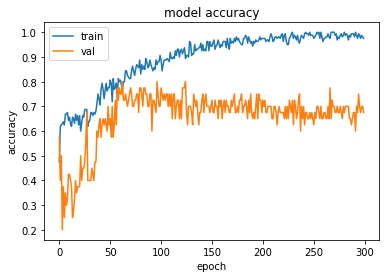

In [15]:
from matplotlib import pyplot as plt
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig('model_accuracy_CNN.png')
plt.show()
#75

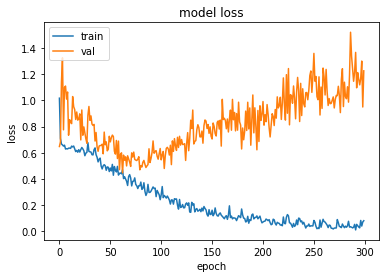

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


In [17]:
from google.colab import files
import pandas as pd
files.download('/content/best_modelcnn')

FileNotFoundError: ignored